In [78]:
import pandas as pd
import numpy as np

import os 
import sys
from subprocess import Popen, PIPE
from io import StringIO
from sklearn.decomposition import PCA
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import ShuffleSplit,  cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn import svm


In [79]:
## read data
cmd = 'find ../DataSetFiles/raw/watch/gyro/ -name "*.txt"'
run = Popen(cmd, shell=True, stdout=PIPE, stderr=PIPE)
cmd_out, cmd_err = run.communicate()
cmd_out = cmd_out.decode().split()
tg = []
for f in cmd_out:
    df = pd.read_csv(f, names=['Subject', 'Task', 'ID', 'x', 'y', 'z'])
    df['z'] = df['z'].str.replace(';', '').astype(float)
#     print(df['Task'].unique())
    tg.append(df)


In [80]:
out = pd.concat(tg, axis=0)
out = out.set_index('Task').drop(columns=['Subject', 'ID'])
out

,x,y,z
Task,,,
A,0.418050,-1.053929,1.149950
A,-1.676260,-0.494665,1.602687
A,1.942443,-0.653389,-0.230633
A,1.781588,-1.616388,-1.506820
A,0.279565,-0.964446,-1.309746
...,...,...,...
S,-1.073295,-0.204933,-0.385017
S,0.467077,-0.545817,-0.487282
S,0.801570,-0.868592,-0.810057


In [81]:
### sliding window-pool into 2000 bins per group
splits = []
for n, grp in out.groupby('Task'):
        label =1 if n in ['H', 'I', 'J', 'K', 'L'] else 0
        data = np.array_split(np.array(grp), 2000)
        for i in range(len(data)):
            pooled_point = np.insert(np.mean(data[i], axis=0), 0, label)
            splits.append(pooled_point)

transformed_data = pd.DataFrame(splits, columns=['label', 'x', 'y', 'z'])
transformed_data

,label,x,y,z
0,0.0,0.043247,-0.011562,-0.176515
1,0.0,0.067314,-0.036341,0.008949
2,0.0,0.036013,0.015395,0.048429
3,0.0,0.001186,0.009044,0.048845
4,0.0,0.006920,0.009272,0.014701
...,...,...,...,...
35995,0.0,-0.041946,0.034020,-0.110503
35996,0.0,-0.159607,0.010705,0.159158
35997,0.0,0.055531,0.036716,-0.030205
35998,0.0,-0.059628,-0.020831,-0.060608


In [82]:
## feature engineering if necessary , do here or above

In [83]:
### split to train test val 
X, y = transformed_data.loc[:, ['x','y','z']].to_numpy(), transformed_data.loc[:, 'label'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

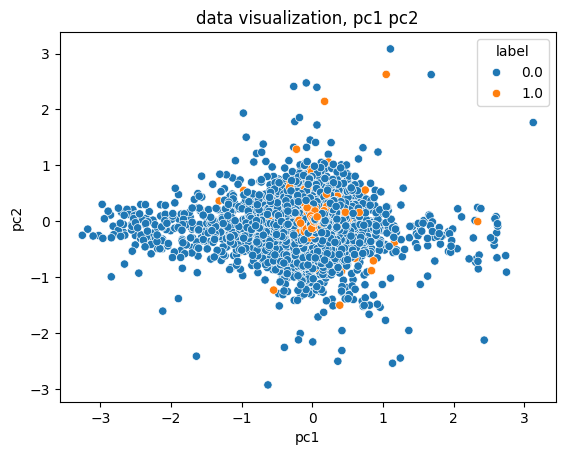

In [84]:
pca = PCA(n_components=3)
X_train_transformed =pca.fit_transform(X_train)
X_train_df= pd.DataFrame(X_train_transformed, columns=['pc1', 'pc2', 'pc3'])
X_train_df['label'] = y_train
X_test_transformed = pca.transform(X_test)
## check pc1 vs pc2
sns.scatterplot(data=X_train_df, x='pc1', y='pc2', hue='label')
plt.title('data visualization, pc1 pc2')
plt.show()

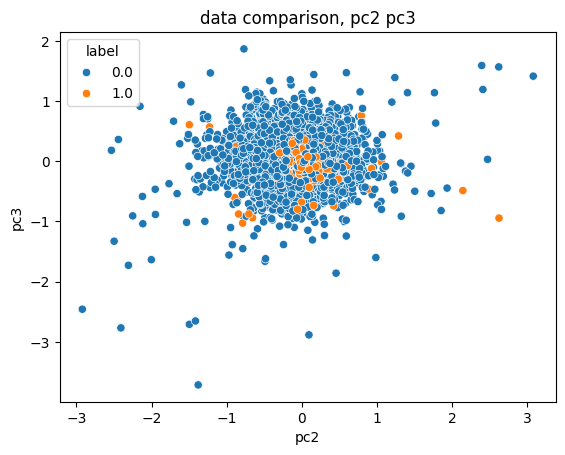

In [85]:
sns.scatterplot(data=X_train_df, x='pc2', y='pc3', hue='label')
plt.title('data comparison, pc2 pc3')
plt.show()

In [86]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [87]:
def get_metrics(y_true, y_pred):
    acc = np.equal(y_true, y_pred).mean()
    auroc = sklearn.metrics.roc_auc_score(y_true, y_pred)
    precision, recall, _ = sklearn.metrics.precision_recall_curve(y_true, y_pred)
    aupr = sklearn.metrics.auc(recall, precision)
    metrics = {'acc': acc,
              'auroc': auroc,
              'aupr': aupr}
    return metrics



## Fit on one set of params

In [93]:
## fit ML models - only one set of params being checked
# svm, decision tree, logistic regression

## one set of params
cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)

decision_tree_clf = DecisionTreeClassifier(random_state=1)
## imbalanced datast, 
svm_clf = svm.SVC(kernel="rbf", gamma=0.2, C=1.0)

decision_tree_clf.fit(X_train_transformed, y_train)
svm_clf.fit(X_train_transformed, y_train)


SVC(gamma=0.2)

## Cross-validation?

In [94]:
# ## kfold split, only one set of params being loaded
dt_cval  = cross_val_score(decision_tree_clf, X_train_transformed, y_train, cv=cv).mean() # this does fitting
svm_cval = cross_val_score(svm_clf,           X_train_transformed, y_train, cv=cv).mean() # this does fitting
svm_cval

0.7222916666666667

## Predictions on one set of params fit

In [99]:
dt_preds = decision_tree_clf.predict(X_test_transformed)
svm_preds = svm_clf.predict(X_test_transformed)


decision_tree_preds_counts = np.unique(dt_preds, return_counts=True)
svm_preds_counts = np.unique(svm_preds, return_counts=True)
print('decision_tree predictions: ', decision_tree_preds)
print('support vector machine predictions: ', svm_preds_counts)

decision_tree predictions:  (array([0., 1.]), array([5079, 2121]))
support vector machine predictions:  (array([0.]), array([7200]))


### Weird on SVM only predicting negative, is it because of imbalanced ytrain?

In [104]:
print('Ytrain data balance')
print(np.unique(y_train, return_counts=True))            # Should show at least two classes

Ytrain data balance
(array([0., 1.]), array([20821,  7979]))


In [106]:
def get_metrics(y_true, y_pred):
    acc = np.equal(y_true, y_pred).mean()
    auroc = sklearn.metrics.roc_auc_score(y_true, y_pred)
    precision, recall, _ = sklearn.metrics.precision_recall_curve(y_true, y_pred)
    aupr = sklearn.metrics.auc(recall, precision)
    metrics = {'acc': acc,
              'auroc': auroc,
              'aupr': aupr}
    return metrics

decision_tree_metrics = get_metrics(y_test, dt_preds)
svm_metrics = get_metrics(y_test, svm_preds)
print('decision tree metrics: ', decision_tree_metrics, 
     '\nsvm metrics: ', svm_metrics)

decision tree metrics:  {'acc': 0.6352777777777778, 'auroc': 0.555941815417743, 'aupr': 0.4539285561190246} 
svm metrics:  {'acc': 0.7193055555555555, 'auroc': 0.5, 'aupr': 0.6403472222222222}


In [107]:
## grid search , hyperparam tuning
dt_grid = {'max_depth': np.random.randint(0, 21, size=5),
           'min_samples_leaf': np.random.randint(0, 11, size=5)}

svm_grid = {'C': [0.1, 0.5, 1, 10],
            'gamma': ['scale', 0.1, 0.5, 1.0]}

dt_search  = RandomizedSearchCV(DecisionTreeClassifier(random_state=1, class_weight='balanced'),
                                param_distributions=dt_grid, n_iter=5 #sample how many times
                                , cv=cv)
svm_search = RandomizedSearchCV(svm.SVC(kernel='rbf', class_weight='balanced'), n_iter=5 ,
                                param_distributions=svm_grid, cv=cv,  n_jobs=-1)

dt_search.fit(X_train_transformed, y_train)
svm_search.fit(X_train_transformed, y_train)

print(dt_search.best_score_, dt_search.best_params_)
print(svm_search.best_score_, svm_search.best_params_)


0.6009722222222222 {'min_samples_leaf': 2, 'max_depth': 18}
0.4765277777777778 {'gamma': 'scale', 'C': 1}


In [108]:
print('dt grid search results: best_score: ',dt_search.best_score_, 'best params', dt_search.best_params_)
print('svm grid searh results: best_score: ', svm_search.best_score_, 'best params', svm_search.best_params_)
from sklearn.metrics import classification_report


dt grid search results: best_score:  0.6009722222222222 best params {'min_samples_leaf': 2, 'max_depth': 18}
svm grid searh results: best_score:  0.4765277777777778 best params {'gamma': 'scale', 'C': 1}


In [109]:
##get best model
best_decision_tree_clf = dt_search.best_estimator_
best_svm_clf = svm_search.best_estimator_

decision_tree_clf, svm_clf

(DecisionTreeClassifier(random_state=1), SVC(gamma=0.2))

## Grid search results randomized

<u>dt grid search results: best_score:  0.7222453703703704 best params {'max_depth': 5, 'min_samples_leaf': 5}</u>

<u>svm grid searh results: best_score:  0.7223148148148149 best params {'C': 10, 'gamma': 1.0}</u>

In [112]:
## dt and svm preds
dt_preds = best_decision_tree_clf.predict(X_test_transformed)
svm_preds = best_svm_clf.predict(X_test_transformed)

print('best dt preds: ', np.unique(dt_preds, return_counts=True))
print('best svm preds: ', np.unique(svm_preds, return_counts=True))


best dt preds:  (array([0., 1.]), array([3949, 3251]))
best svm preds:  (array([0., 1.]), array([1694, 5506]))


In [113]:
print('Decision Tree metrics: ', get_metrics(y_test, dt_preds))
print('SVM preds: ', get_metrics(y_test, svm_preds))

Decision Tree metrics:  {'acc': 0.6130555555555556, 'auroc': 0.6136612106956891, 'aupr': 0.5527207540644484}
SVM preds:  {'acc': 0.47680555555555554, 'auroc': 0.6150486984557493, 'aupr': 0.6456307935388315}


In [114]:
np.unique(svm_preds, return_counts=True)
np.unique(dt_preds, return_inverse=True, return_index=True, return_counts=True)


(array([0., 1.]),
 array([1, 0]),
 array([1, 0, 1, ..., 1, 0, 0]),
 array([3949, 3251]))

In [ ]:
svm_preds